# Walk Forward Validation Analysis and Model Selection
In this notebook, we explore the results of the walk-forward validation experiment, portfolio performances. Eventually, these are used to selected models that will be passed on to the testing stage on completely unseen data with no look ahead bias.

### Setup:

In [55]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.graph_objects as go
from src.utils.io import load_path_config
from src.data_processing.loading import load_csv_files, ArtifactDataExtractor
from src.evaluation.evaluator import filter_models
from sklearn.decomposition import PCA
from src.utils.window import calc_current_idxs, get_date_index_col
from sklearn.preprocessing import StandardScaler
from src.visualization.plots import plot_windowed_comparison
from src.utils.constants import EQ_WT_NAME, SP500_NAME

from src.models.registry import TradModelLibrary, NNModelLibrary

In [56]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

In [ ]:

grid_mode = 'one_model'
model_name = None
loss_name = None # Change previous grid mode if needed

extractor = ArtifactDataExtractor(grid_mode, artifacts_paths)

if grid_mode == 'one_model':
    # Get all models from library
    all_models = []
    for cat in NNModelLibrary.list_categories():
        all_models.extend(NNModelLibrary.list_models(cat))

    all_avg_perf = extractor.agg_avg_perf('avg_perf', all_models)
    opti_hparams = extractor.agg_opti_hparams('optimized', all_models)
    # all_daily_rets = extractor.agg_daily_rets('daily_rets', all_models)

    #### Remove custom losses 13 and 14 ####
    mask = all_avg_perf.index.str.contains('-custom_loss_13|-custom_loss_14')
    all_avg_perf = all_avg_perf[~mask]
    
elif grid_mode == 'one' and model_name is not None and loss_name is not None:
    opti_hparams = extractor.agg_opti_hparams(
        'optimized', [f'{model_name}-{loss_name}']
    )
    filtered_models = None

{'artifacts_dir': PosixPath('../artifacts'), 'results_dir': PosixPath('../artifacts/results'), 'avg_perf_dir': PosixPath('../artifacts/results/avg_performance'), 'hparams_dir': PosixPath('../artifacts/results/optimized_hparams'), 'plots_dir': PosixPath('../artifacts/results/plots'), 'tuned_plots_dir': PosixPath('../artifacts/results/plots/tuned_plots'), 'wfv_plots_dir': PosixPath('../artifacts/results/plots/wfv_plots'), 'wfv_rets_dir': PosixPath('../artifacts/results/wfv_returns'), 'temp_dir': PosixPath('../artifacts/temp'), 'test_plots_dir': PosixPath('../artifacts/results/plots/test_plots'), 'test_perf_dir': PosixPath('../artifacts/results/test_performance')}
AVG_PERF file for DeformTime not found at DeformTime. Skipping!
OPTIMIZED file for DeformTime not found at DeformTime. Skipping!


In [63]:
# all_benches = TradModelLibrary.list_models()
all_benches = [EQ_WT_NAME, SP500_NAME]

# Filter models that beat Equal Weight Portfolio
filtered_perf, filtered_models = filter_models(
    all_avg_perf, EQ_WT_NAME, 'sharpe', all_benches
)

print(f'\n {len(filtered_models)} Models beat Equal Weight portfolio.')
# print('Filtered Avg. Performance Metrics: \n', filtered_perf)
filtered_perf = filtered_perf.sort_values(by='sharpe', ascending=False)
filtered_perf


 7 Models beat Equal Weight portfolio.


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_10,0.124800,0.121213,0.202425,-0.144175,-0.044050,1.442350,0.033450
TemporalTransformer-custom_loss_11,0.096713,0.120262,0.206937,-0.107100,-0.034050,1.383037,0.024625
PatchTST-custom_loss_12,0.132513,0.118813,0.198150,-0.125487,-0.043550,1.435712,0.032275
InvertedAttentionLSTM-custom_loss_10,0.080863,0.111250,0.162038,-0.096138,-0.034200,1.378388,0.023438
AttentionLSTM-custom_loss_12,0.082263,0.110175,0.173538,-0.125850,-0.040612,1.378400,0.023338
InvertedAttentionLSTM-custom_loss_6,0.058775,0.108625,0.167387,-0.096087,-0.032012,1.373862,0.022812
InvertedAttentionLSTM-custom_loss_12,0.057987,0.108512,0.165075,-0.096312,-0.032162,1.374888,0.022850
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125


In [64]:
all_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_6,0.055175,0.104838,0.152362,-0.099425,-0.034225,1.350763,0.021112
TemporalTransformer-custom_loss_10,0.111350,0.066325,0.113400,-0.168650,-0.054175,1.236163,0.016588
TemporalTransformer-custom_loss_11,0.096713,0.120262,0.206937,-0.107100,-0.034050,1.383037,0.024625
TemporalTransformer-custom_loss_12,0.057250,0.106762,0.163400,-0.095900,-0.031700,1.374100,0.022400
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125
PatchTST-custom_loss_6,0.082950,0.081337,0.165837,-0.174787,-0.061337,1.264050,0.020350
PatchTST-custom_loss_10,0.052262,0.088887,0.131988,-0.115900,-0.037112,1.295587,0.017500
PatchTST-custom_loss_11,0.077475,0.080138,0.143712,-0.129550,-0.039412,1.268750,0.021763
PatchTST-custom_loss_12,0.132513,0.118813,0.198150,-0.125487,-0.043550,1.435712,0.032275


## Mean Sharpe Analysis
### Overall View

Models/Approaches that BEAT Equal Weight Mean Sharpe:


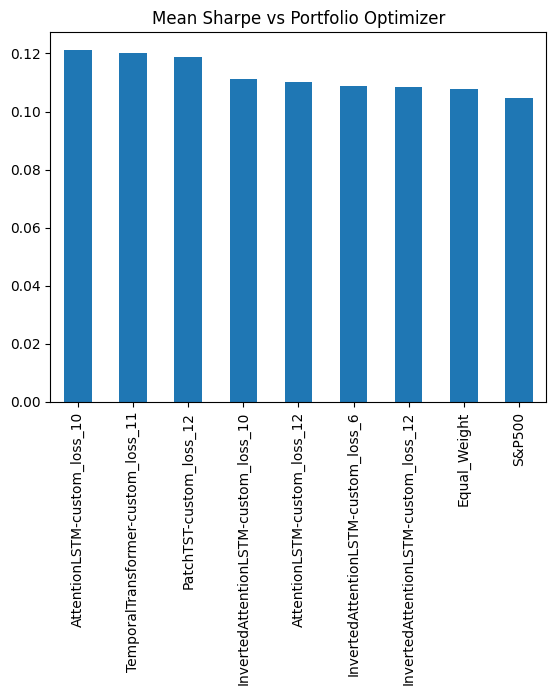

In [65]:

filtered_perf['sharpe'].plot.bar(title='Mean Sharpe vs Portfolio Optimizer')
print('Models/Approaches that BEAT Equal Weight Mean Sharpe:')

In [66]:
print('Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:')
no_beat = all_avg_perf.drop(filtered_perf.index, axis=0)
print(f'{len(no_beat)} NN models did not beat Equal Weight Portfolio:')
no_beat

Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:
17 NN models did not beat Equal Weight Portfolio:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_6,0.055175,0.104838,0.152362,-0.099425,-0.034225,1.350763,0.021112
TemporalTransformer-custom_loss_10,0.111350,0.066325,0.113400,-0.168650,-0.054175,1.236163,0.016588
TemporalTransformer-custom_loss_12,0.057250,0.106762,0.163400,-0.095900,-0.031700,1.374100,0.022400
PatchTST-custom_loss_6,0.082950,0.081337,0.165837,-0.174787,-0.061337,1.264050,0.020350
PatchTST-custom_loss_10,0.052262,0.088887,0.131988,-0.115900,-0.037112,1.295587,0.017500
PatchTST-custom_loss_11,0.077475,0.080138,0.143712,-0.129550,-0.039412,1.268750,0.021763
BaseLSTM-custom_loss_6,0.078487,0.088225,0.151700,-0.110900,-0.036975,1.305375,0.021862
BaseLSTM-custom_loss_10,0.066912,0.095687,0.147863,-0.111338,-0.037012,1.326437,0.020237
BaseLSTM-custom_loss_11,0.051825,0.079450,0.116175,-0.126325,-0.038375,1.242538,0.015125
BaseLSTM-custom_loss_12,0.054337,0.096388,0.139838,-0.102750,-0.033500,1.313125,0.017900


In [69]:
# Split Benchmarks and filtered models

benchmarks_df = all_avg_perf[all_avg_perf.index.isin(all_benches)]
all_avg_perf = all_avg_perf[~all_avg_perf.index.isin(all_benches)]

## Multi Metric Analysis:

### Correlation Analysis

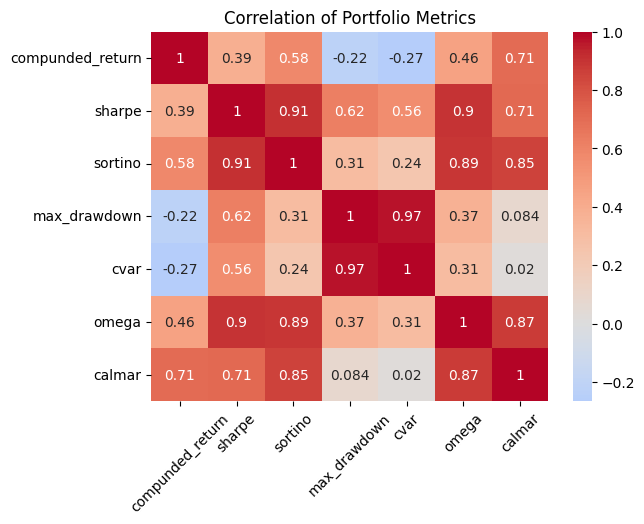

In [70]:
corr = all_avg_perf.corr()

# Plot heatmap
plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation of Portfolio Metrics')
plt.xticks(rotation=45)
plt.show()

In [72]:
def high_corr_with_each_metric(corr, threshold=0.8):
    for metric in corr.columns:
        # Exclude self (corr=1.0)
        others = corr[metric][corr[metric].index != metric]
        high = others[abs(others) > threshold]
        if not high.empty:
            print(f"\n{metric} is highly correlated with:")
            for name, val in high.items():
                print(f"  {name}: {val:.3f}")

high_corr_with_each_metric(corr, threshold=0.75)


sharpe is highly correlated with:
  sortino: 0.907
  omega: 0.898

sortino is highly correlated with:
  sharpe: 0.907
  omega: 0.894
  calmar: 0.855

max_drawdown is highly correlated with:
  cvar: 0.973

cvar is highly correlated with:
  max_drawdown: 0.973

omega is highly correlated with:
  sharpe: 0.898
  sortino: 0.894
  calmar: 0.872

calmar is highly correlated with:
  sortino: 0.855
  omega: 0.872


Most metrics are highly correlated with each other, with omega and sharpe showing high correlation with most of the other metrics. We can choose Sharpe, Calmar and maybe even CVaR to be our main metrics. CVaR and MDD are highly correlated so we can have one of them to add in loss like or bad scenarios.

##### Principle Component Analysis:

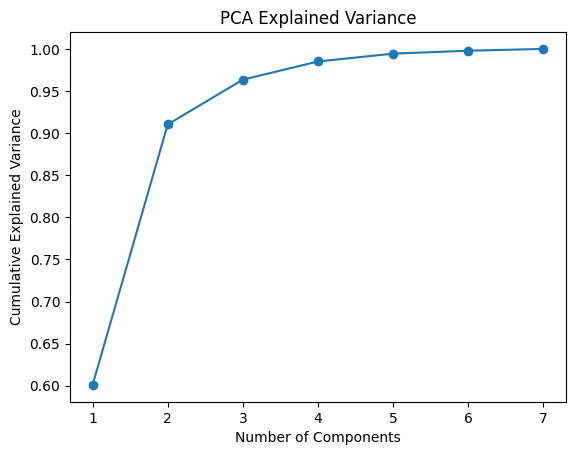

In [73]:
scaler = StandardScaler()
scaled_perf = scaler.fit_transform(all_avg_perf)

pca = PCA()
pca.fit(scaled_perf)

# Explained variance ratio
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.plot(range(1, len(explained)+1), cumulative, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

The first principle component explains ~ 25% of the variance. At 6 princple components, almost 100% of the variance is explained.

In [74]:
loadings = pca.components_.T 

def print_important_metrics(loadings, metrics, n_components=5, top_n=3):
    for i in range(n_components):
        # Get loadings for component i
        comp_loadings = loadings[:, i]
        # Sort by absolute value
        sorted_idx = np.argsort(np.abs(comp_loadings))[::-1]
        print(f"\nPrincipal Component {i+1} (explained variance: {pca.explained_variance_ratio_[i]:.3f})")
        for j in range(top_n):
            idx = sorted_idx[j]
            print(f"  {metrics[idx]}: {comp_loadings[idx]:.3f}")

# Example:
print_important_metrics(loadings, all_avg_perf.columns, n_components=6, top_n=3)


Principal Component 1 (explained variance: 0.601)
  sharpe: 0.470
  sortino: 0.462
  omega: 0.461

Principal Component 2 (explained variance: 0.309)
  cvar: 0.592
  max_drawdown: 0.571
  compunded_return: -0.459

Principal Component 3 (explained variance: 0.053)
  compunded_return: 0.813
  omega: -0.403
  cvar: 0.272

Principal Component 4 (explained variance: 0.022)
  calmar: 0.646
  sortino: -0.545
  sharpe: -0.421

Principal Component 5 (explained variance: 0.009)
  omega: 0.616
  sortino: -0.520
  calmar: -0.458

Principal Component 6 (explained variance: 0.003)
  cvar: 0.701
  max_drawdown: -0.687
  sortino: 0.151


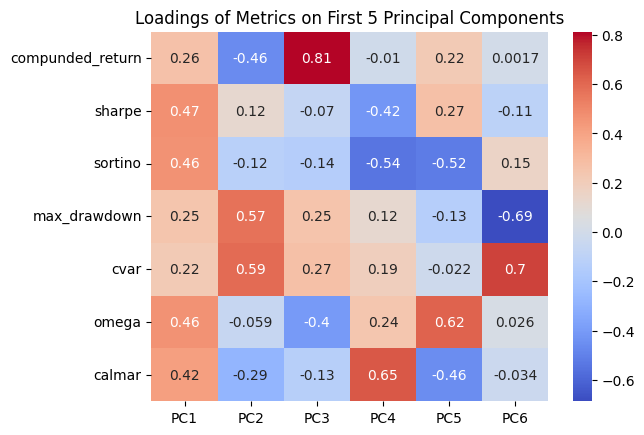

In [75]:
plt.figure()
sns.heatmap(loadings[:, :6], annot=True, cmap='coolwarm', 
            xticklabels=[f'PC{i+1}' for i in range(6)],
            yticklabels=all_avg_perf.columns)
plt.title('Loadings of Metrics on First 5 Principal Components')
plt.show()

PC1 (explains 50.0% of variance) – High positive loadings on Sharpe (0.50), Omega (0.48), and Sortino (0.48).
- PC1 captures risk‑adjusted return (higher is better).
PC2 (explains 27.8% of variance) – High positive loading on CVaR (0.58) (which is undesirable) and negative loadings on Calmar (–0.46) and compounded return (–0.46) (both desirable).
- Higher PC2 indicates higher tail risk, lower drawdown‑adjusted return, and lower raw return – i.e., worse overall.
- To align with “higher is better”, we invert PC2 (use –PC2). Then –PC2 represents low tail risk, high Calmar, and high raw return.
PC3 (explains 12.9% of variance) – High positive loading on compounded return (0.76) but also positive on CVaR (0.33) and negative on Calmar (–0.48). This component is ambiguous (higher raw return comes with higher tail risk and lower Calmar), so we do not use it for Pareto selection.
Thus, we construct a 2D Pareto frontier using PC1 (risk‑adjusted return) and –PC2 (low tail risk + high Calmar/return). Both dimensions are “higher is better”, providing a clear, interpretable trade‑off. This approach leverages the PCA results while avoiding the complexity of a third dimension.

For robustness, we also consider the original metrics Sharpe (primary), Calmar (drawdown control), and CVaR (tail risk) as a sanity check. However, the PC1 + –PC2 combination already captures the same information in a more balanced way.

##### Pareto Frontier with Top 2 Principle Components

In [77]:
# Transform the standardized data (already filtered to models only, no benchmarks)
pca_scores = pca.transform(scaled_perf)   # shape (n_models, n_components)

pc_df = pd.DataFrame({
    'model': all_avg_perf.index,
    'PC1': pca_scores[:, 0],
    'PC2_inv': -pca_scores[:, 1]          # invert so higher is better
})

In [78]:
def is_dominated(row, df):
    for _, other in df.iterrows():
        if (other['PC1'] >= row['PC1'] and other['PC2_inv'] >= row['PC2_inv'] and
            (other['PC1'] > row['PC1'] or other['PC2_inv'] > row['PC2_inv'])):
            return True
    return False

pc_df['dominated'] = pc_df.apply(lambda r: is_dominated(r, pc_df), axis=1)
frontier = pc_df[~pc_df['dominated']].copy()

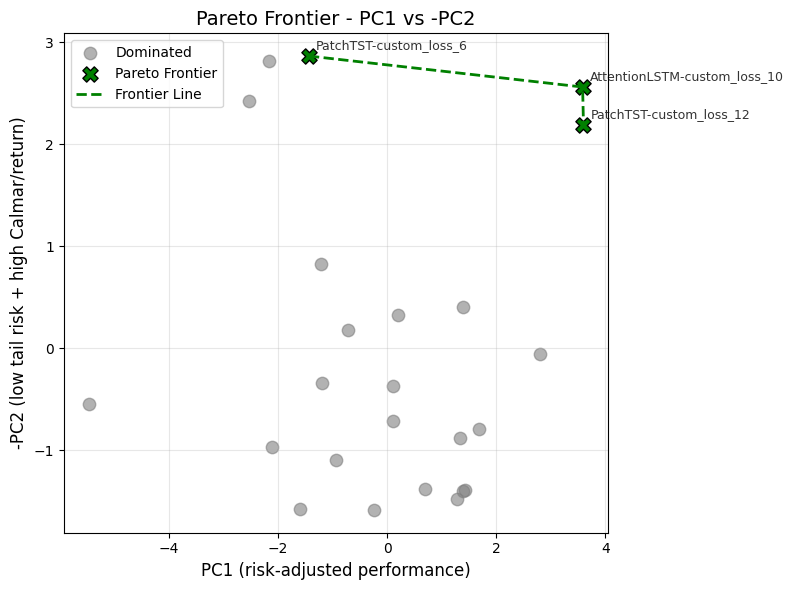

In [79]:
frontier_sorted = frontier.sort_values('PC1')

plt.figure(figsize=(8,6))

# Dominated models
plt.scatter(pc_df[pc_df['dominated']]['PC1'], pc_df[pc_df['dominated']]['PC2_inv'],
            c='gray', s=80, alpha=0.6, label='Dominated')

# Frontier models
plt.scatter(frontier['PC1'], frontier['PC2_inv'],
            c='green', marker='X', s=120, edgecolors='black', label='Pareto Frontier')

# Frontier line
plt.plot(frontier_sorted['PC1'], frontier_sorted['PC2_inv'],
         linestyle='--', color='green', linewidth=2, label='Frontier Line')

# Annotations
for _, row in frontier.iterrows():
    plt.annotate(row['model'], (row['PC1'], row['PC2_inv']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)

plt.xlabel('PC1 (risk-adjusted performance)', fontsize=12)
plt.ylabel('-PC2 (low tail risk + high Calmar/return)', fontsize=12)   # update label
plt.title('Pareto Frontier - PC1 vs -PC2', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
fig = px.scatter_3d(
    all_avg_perf,
    x='sharpe',
    y='compunded_return',
    z='cvar',
    hover_name=all_avg_perf.index,
    color='sharpe',                # color by Sharpe (or any metric)
    title='3D Pareto Frontier: Sharpe, Calmar, CVaR',
    labels={
        'sharpe': 'Sharpe Ratio',
        'compunded_return': 'Compunded Return',
        'cvar': 'CVaR (higher better)'
    }
)

# Update marker size and appearance
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

# Optional: add a plane or highlight the Pareto frontier (more complex)
# For simplicity, just show the points.

fig.show()

In [82]:
def is_dominated_3d(row, df, cols):
    for _, other in df.iterrows():
        if (other[cols[0]] >= row[cols[0]] and
            other[cols[1]] >= row[cols[1]] and
            other[cols[2]] >= row[cols[2]] and
            (other[cols[0]] > row[cols[0]] or
             other[cols[1]] > row[cols[1]] or
             other[cols[2]] > row[cols[2]])):
            return True
    return False

all_avg_perf = all_avg_perf.copy()
cols = ['sharpe', 'compunded_return', 'cvar']
all_avg_perf['dominated_3d'] = all_avg_perf.apply(lambda r: is_dominated_3d(r, all_avg_perf, cols), axis=1)
frontier_3d = all_avg_perf[~all_avg_perf['dominated_3d']]


# Build the figure
fig = go.Figure()

# 1. Dominated models (dark gray)
fig.add_trace(go.Scatter3d(
    x=all_avg_perf[all_avg_perf['dominated_3d']]['sharpe'],
    y=all_avg_perf[all_avg_perf['dominated_3d']]['compunded_return'],
    z=all_avg_perf[all_avg_perf['dominated_3d']]['cvar'],
    mode='markers',
    marker=dict(size=5, color='gray', opacity=0.6),
    text=all_avg_perf[all_avg_perf['dominated_3d']].index,
    hovertemplate='<b>%{text}</b><br>Sharpe: %{x:.3f}<br>Compounded Ret: %{y:.3f}<br>CVaR: %{z:.3f}<extra></extra>',
    name='Dominated'
))

# 2. Frontier models (green)
fig.add_trace(go.Scatter3d(
    x=frontier_3d['sharpe'],
    y=frontier_3d['compunded_return'],
    z=frontier_3d['cvar'],
    mode='markers',
    marker=dict(size=10, color='green', symbol='diamond'),
    text=frontier_3d.index,
    hovertemplate='<b>%{text}</b><br>Sharpe: %{x:.3f}<br>Compounded Ret: %{y:.3f}<br>CVaR: %{z:.3f}<extra></extra>',
    name='Pareto Frontier'
))

# Optional: Add a line connecting frontier points (if you still want it)
# Sort frontier by Sharpe for a plausible line (but interpret with caution)
frontier_sorted = frontier_3d.sort_values('sharpe', ascending=False)
fig.add_trace(go.Scatter3d(
    x=frontier_sorted['sharpe'],
    y=frontier_sorted['compunded_return'],
    z=frontier_sorted['cvar'],
    mode='lines',
    line=dict(color='green', width=2, dash='dash'),
    showlegend=False,
    hoverinfo='skip'
))

fig.update_layout(
    title='3D Pareto Frontier (Sharpe, Compounded Ret, CVaR)',
    scene=dict(
        xaxis_title='Sharpe',
        yaxis_title='Compounded Ret',
        zaxis_title='CVaR (higher better)'
    ),
    legend=dict(x=0.8, y=0.9)
)

fig.show()

In [26]:
# Efficient frontier models vs Benchmarks
frontier_model_names = list(frontier_3d.index)
pd.concat([frontier_3d, benchmarks_df], axis=0)

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated_3d
PatchTST-custom_loss_10,0.089637,0.106687,0.182638,-0.141063,-0.040837,1.387150,0.027625,False
BaseLSTM-custom_loss_6,0.057400,0.107612,0.165150,-0.095912,-0.031962,1.373750,0.023012,False
BaseLSTM-custom_loss_12,0.057000,0.107375,0.162950,-0.096113,-0.031738,1.373775,0.022613,False
AttentionLSTM-custom_loss_10,0.059487,0.109537,0.166538,-0.096350,-0.032400,1.374437,0.023000,False
AttentionLSTM-custom_loss_11,0.070450,0.120963,0.183912,-0.099687,-0.033337,1.423225,0.025625,False
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575,NaN
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125,NaN


#### Daily Returns for the frontier models

In [83]:
processed_files = {
    'returns_val': Path(paths_config['processed_paths']['returns_val'])
}

processed_dfs = load_csv_files(processed_files, index_dt=True)

def extract_window_dates(returns_val, num_steps, out_size):
    out_wind_idxs = []
    for step in range(1, num_steps+1):
        current_start, current_end = calc_current_idxs(step, out_size)

        out_wind_idxs.append((current_start, current_end))
    
    out_win_date_cols = get_date_index_col(returns_val, out_wind_idxs)

    return out_win_date_cols


out_win_date_cols = extract_window_dates(processed_dfs['returns_val'], 8, 60)

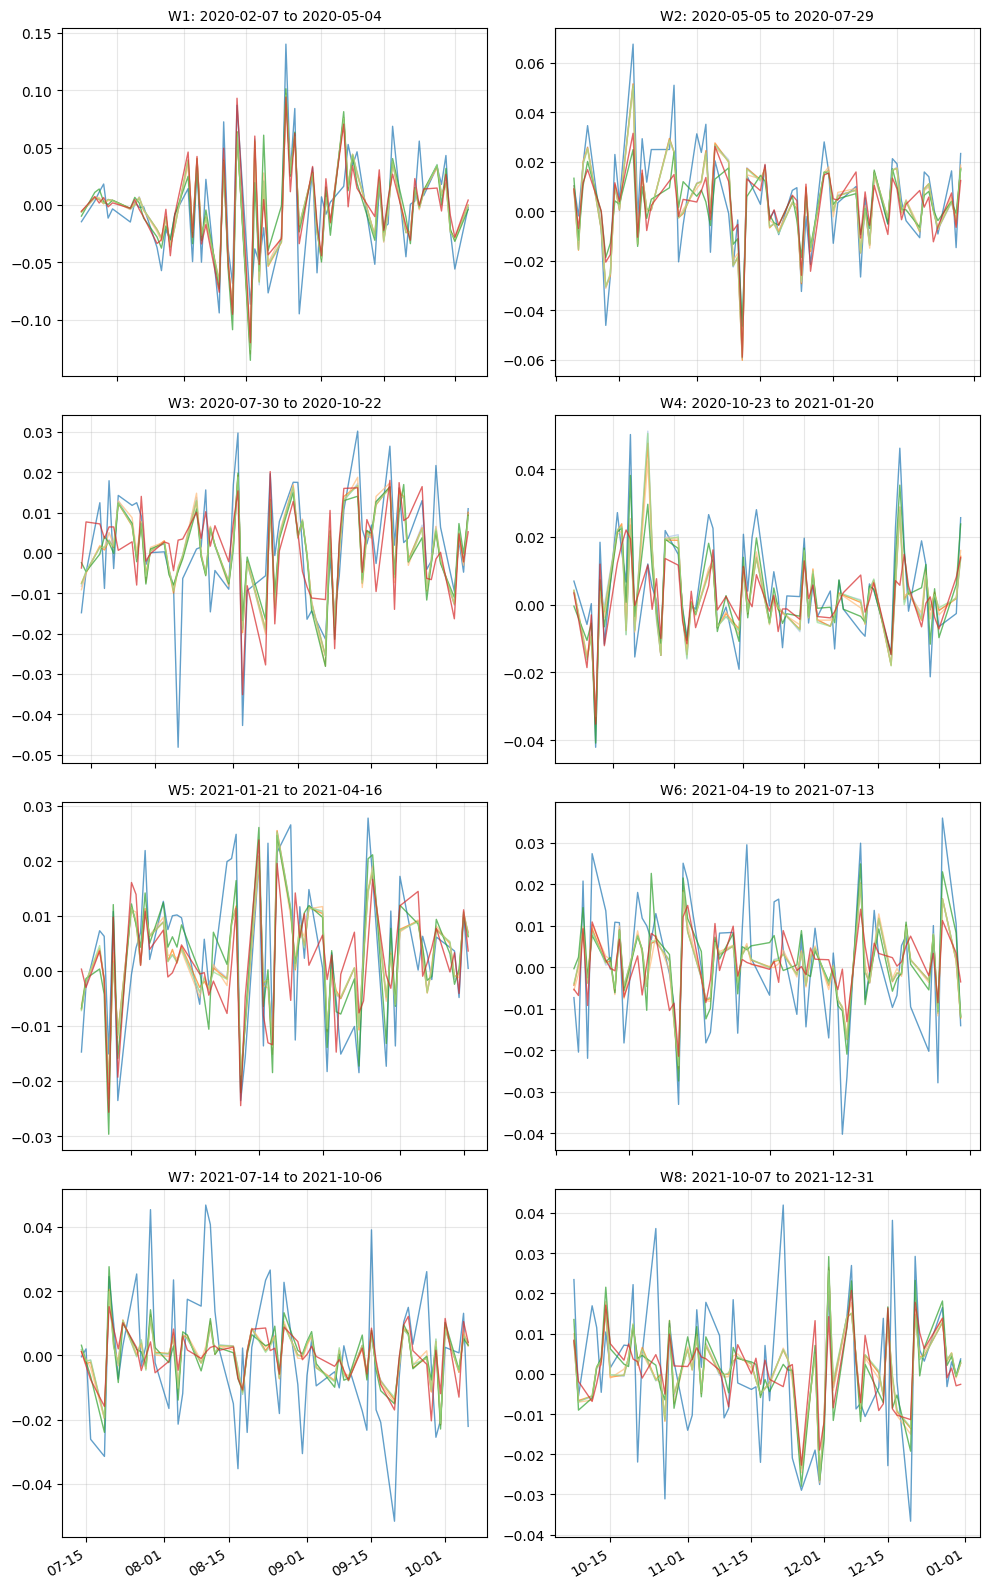

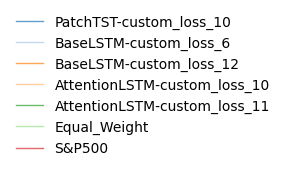

In [84]:
if all_daily_rets:    
    frontier_daily_rets = {
        k: all_daily_rets[k] for k in frontier_model_names if k in frontier_model_names
    }

    for bench in all_benches:
        bench_rets = all_daily_rets.get(bench)
        if bench_rets:
            frontier_daily_rets.update({bench: bench_rets})

    plot_windowed_comparison(
        all_daily_returns=frontier_daily_rets,
        window_dates=out_win_date_cols,
        windows_per_row=2,
        plot=True
    )
else:
    print('WARNING: No daily returns found.')

#### Training Loss Curves for best performing model loss combination

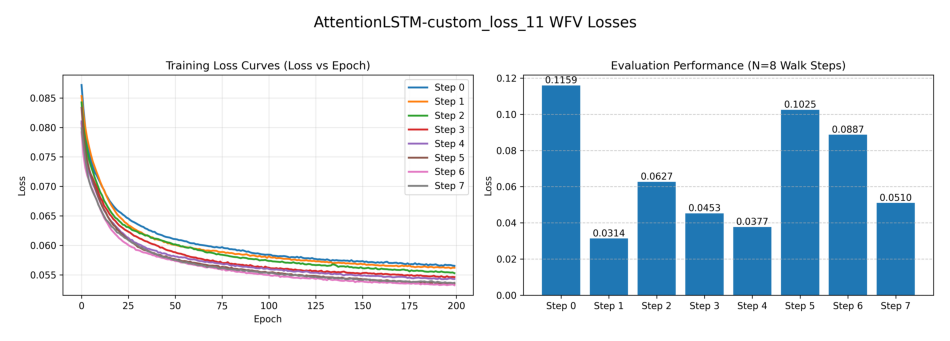

In [35]:
plt.figure(figsize=(12, 8))
img = mpimg.imread(artifacts_paths['tuned_plots_dir'] / 'AttentionLSTM-custom_loss_11 WFV Losses.png')
plt.imshow(img)
plt.axis('off')  # hide axes
plt.show()